### This code provides supports for results in SI section A.12.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,ListedColormap
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.gridspec as gridspec

d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


A

In [2]:
###data sources: census data and accratios
df_census=pd.read_csv('data/census/all_census_data_with_location.csv',
                     usecols=['census_block_group','population_by_age','percent_above_65'])
dfT=df_census
#homo
for key in ['Health Care Services','Grocery and Food Supply','Housing and Real Estate']:
    df_=pd.read_csv('data/A under 5-mile setting/'+key+'.csv',
                       usecols=['census_block_group','demand_met_in_local'])
###data sources: census data and accratios    
    df_=df_.rename(columns={'demand_met_in_local':key+'_accratio5m'})
    dfT=pd.merge(dfT,df_)
dfT['census_block_group']=dfT['census_block_group'].astype(str)
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}
dfT['state']=dfT.apply(lambda x: dict_state[str(int(x['census_block_group'][0:2]))] if 
                                       len(x['census_block_group'])==12 else dict_state[str(int(x['census_block_group'][0:1]))],
                                       axis=1)
dfT['county']=dfT.apply(lambda x: str(int(x['census_block_group'][0:5])) if 
                                       len(x['census_block_group'])==12 else str(int(x['census_block_group'][0:4])),
                                       axis=1)
dfT['is_old']=dfT.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5, axis=1)
dfT['is_old']=dfT.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['is_old'], axis=1)

In [3]:
dfT

,census_block_group,population_by_age,percent_above_65,Health Care Services_accratio5m,Grocery and Food Supply_accratio5m,Housing and Real Estate_accratio5m,state,county,is_old
0,10010201001,745,0.036242,0.574468,0.786667,0.625000,AL,1001,0.0
1,10010201002,1265,0.114625,0.280000,0.443709,0.286689,AL,1001,0.0
2,10010202001,960,0.161458,0.655172,0.809524,0.694611,AL,1001,0.0
3,10010202002,1236,0.094660,0.666667,0.702128,0.741007,AL,1001,0.0
4,10010203001,2364,0.134095,0.292135,0.696629,0.438953,AL,1001,0.0
...,...,...,...,...,...,...,...,...,...
220328,721537506011,921,0.226927,0.000000,1.000000,0.615385,PR,72153,0.5
220329,721537506012,2703,0.107658,0.181818,0.666667,0.257143,PR,72153,0.0
220330,721537506013,1195,0.057741,0.000000,1.000000,0.200000,PR,72153,0.0
220331,721537506021,2005,0.220449,NaN,NaN,0.277778,PR,72153,0.5


In [4]:
city_county_fips = {
    # 佛罗里达州（Florida）
    'Miami': '12086',  # 迈阿密-戴德县
    'Palm Beach': '12099',  # 帕尔姆比奇县     
    # AZ州（Arizona）
    "Phoenix": "4013",  # Maricopa County
    "Tucson": "4019",   # Pima County

    # 加利福尼亚州（California）
    'Los Angeles':"6037",  # 洛杉矶县
    'San Diego': '6073'  # 圣迭戈县
    }
county_dict= {
    # 佛罗里达州（Florida）
    '12086':'Miami-Dade',  # 迈阿密-戴德县
    '12099':'Palm Beach',  # 帕尔姆比奇县     
    # AZ州（Arizona）
     "4013":"Maricopa",  # Maricopa County
     "4019":"Pima",   # Pima County

    # 加利福尼亚州（California）
    "6037":'Los Angeles',  # 洛杉矶县
    '6073':'San Diego' # 圣迭戈县
    }
county_list=list(city_county_fips.values())

In [5]:
df_city=dfT[dfT['county'].isin(county_list)]

def get_key(value):
    return [k for k,v in city_county_fips.items() if v==value][0]
df_city['city']=df_city.apply(lambda x: get_key(x['county']),axis=1)

df_city['county_name']=df_city.apply(lambda x: county_dict[x['county']],axis=1)
df_city=df_city.dropna()
agedict={1:'greater than 0.5',0:'less than 0.2',0.5:'mid'}
df_city['age']=df_city.apply(lambda x: agedict[x['is_old']],axis=1)

C:\Users\Linao\AppData\Local\Temp\ipykernel_32764\4197357535.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_city['city']=df_city.apply(lambda x: get_key(x['county']),axis=1)
C:\Users\Linao\AppData\Local\Temp\ipykernel_32764\4197357535.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_city['county_name']=df_city.apply(lambda x: county_dict[x['county']],axis=1)


In [6]:
df_city

,census_block_group,population_by_age,percent_above_65,Health Care Services_accratio5m,Grocery and Food Supply_accratio5m,Housing and Real Estate_accratio5m,state,county,is_old,city,county_name,age
4331,40130101011,1497,0.077488,0.000000,0.000000,0.004049,AZ,4013,0.0,Phoenix,Maricopa,less than 0.2
4332,40130101012,2100,0.392381,0.000000,0.000000,0.000000,AZ,4013,0.5,Phoenix,Maricopa,mid
4333,40130101013,1189,0.852817,0.076923,0.000000,0.000000,AZ,4013,1.0,Phoenix,Maricopa,greater than 0.5
4334,40130101021,1026,0.313840,0.000000,0.000000,0.000000,AZ,4013,0.5,Phoenix,Maricopa,mid
4335,40130101022,1542,0.512322,0.000000,0.050000,0.091040,AZ,4013,1.0,Phoenix,Maricopa,greater than 0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
49414,120990083021,1206,0.106136,0.431818,0.711712,0.267148,FL,12099,0.0,Palm Beach,Palm Beach,less than 0.2
49415,120990083022,4622,0.065989,0.333333,0.635036,0.343066,FL,12099,0.0,Palm Beach,Palm Beach,less than 0.2
49416,120999800001,0,0.000000,0.200000,0.235294,0.258065,FL,12099,0.0,Palm Beach,Palm Beach,less than 0.2
49418,120999802001,0,0.000000,0.000000,0.000000,0.000000,FL,12099,0.0,Palm Beach,Palm Beach,less than 0.2


In [8]:
#prepath='D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/'
#df_city.to_csv(prepath+'cityCountyLevelAnalysis/6cities_accratio5m_HGH_50_20.csv')  

In [7]:

abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}

for key in abb_dict.keys():  
    sum_y_med=0
    sum_o_med=0
    sum_med=0
    for county in county_dict.values():
        #print(county)
        y_med=np.median(df_city[(df_city['county_name']==county)&(df_city['age']=='less than 0.2')][key+'_accratio5m'])
        o_med=np.median(df_city[(df_city['county_name']==county)&(df_city['age']=='greater than 0.5')][key+'_accratio5m'])
        med=np.median(df_city[(df_city['county_name']==county)][key+'_accratio5m'])
        print (key,y_med,o_med,county)
        

Health Care Services 0.4746982075356664 0.6147954041523886 Miami-Dade
Health Care Services 0.4622641509433962 0.5714285714285714 Palm Beach
Health Care Services 0.4202898550724637 0.5 Maricopa
Health Care Services 0.4791304347826087 0.39871794871794874 Pima
Health Care Services 0.5 0.5245901639344263 Los Angeles
Health Care Services 0.4231853086912617 0.5 San Diego
Grocery and Food Supply 0.6859320147272883 0.7411622276029055 Miami-Dade
Grocery and Food Supply 0.6372549019607843 0.7 Palm Beach
Grocery and Food Supply 0.6444444444444445 0.6559139784946236 Maricopa
Grocery and Food Supply 0.6745725317153888 0.42009400705052874 Pima
Grocery and Food Supply 0.6981132075471698 0.5454545454545454 Los Angeles
Grocery and Food Supply 0.6923076923076923 0.6363636363636364 San Diego
Housing and Real Estate 0.5700136147038801 0.7571825205214872 Miami-Dade
Housing and Real Estate 0.6057347670250897 0.6652542372881356 Palm Beach
Housing and Real Estate 0.5794117647058824 0.6182795698924731 Maricopa

fairindex

In [8]:
abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}
homoDD13C=[]

for key in abb_dict.keys():   
    for county in county_list:
        df_st=df_city[(df_city['county']==county)&(df_city['is_old']!=0.5) ]
        numold=sum(df_st['is_old'])
        if numold>0:
            sumfair=0
            for i in range(9):
                thres = np.percentile(df_st[(df_st['age']=='less than 0.2')&(df_st[key+'_accratio5m']<=1)][key+'_accratio5m'],i*10+10) 
                numGood = len(df_st[(df_st[key+'_accratio5m']>=thres)&(df_st['age']=='greater than 0.5')&(df_st[key+'_accratio5m']<=1)])                         
                fairindex = numGood/numold-(1-(i*10+10)/100)
                sumfair += fairindex
            FairIndex = sumfair/4.5
            homoDD13C.append((key,county,county_dict[county],FairIndex,'5 miles'))

homoDD13Cdf=pd.DataFrame(homoDD13C,columns=['parentType','county','county_name','FairIndex','coverage'])

In [9]:
homoDD13Cdf

,parentType,county,county_name,FairIndex,coverage
0,Health Care Services,12086,Miami-Dade,0.412698,5 miles
1,Health Care Services,12099,Palm Beach,0.403509,5 miles
2,Health Care Services,4013,Maricopa,0.235867,5 miles
3,Health Care Services,4019,Pima,-0.078431,5 miles
4,Health Care Services,6037,Los Angeles,0.111111,5 miles
5,Health Care Services,6073,San Diego,0.084967,5 miles
6,Grocery and Food Supply,12086,Miami-Dade,0.174603,5 miles
7,Grocery and Food Supply,12099,Palm Beach,0.234568,5 miles
8,Grocery and Food Supply,4013,Maricopa,0.069526,5 miles
9,Grocery and Food Supply,4019,Pima,-0.535948,5 miles


In [12]:
#prepath='D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/'
#homoDD13Cdf.to_csv(prepath+'cityCountyLevelAnalysis/6counties_fairindex5m_HGH_50_20.csv')  

In [12]:
df_city['age']=df_city['age'].apply(lambda x:'>50' if x=='greater than 0.5' else '<20')

quantile:  36
quantile:  36
quantile:  36


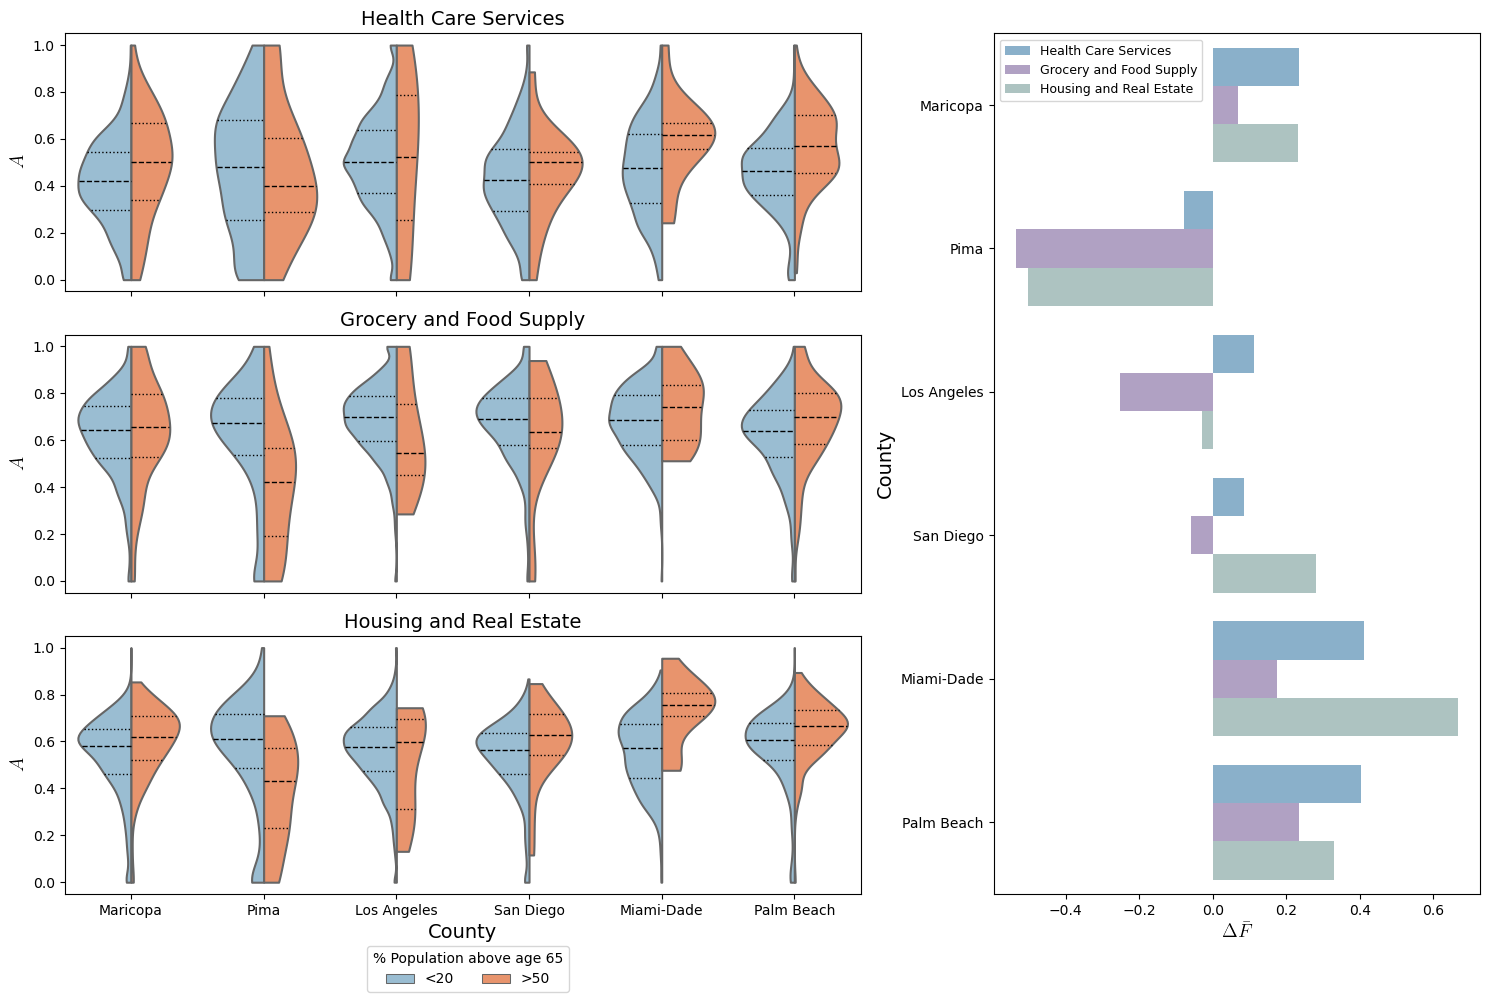

In [18]:

#plot

fig=plt.figure(figsize=(15, 10))

gs=gridspec.GridSpec(3,5)

ax=[]
for i in range(3):
    ax.append(plt.subplot(gs[i,0:3]))
ax.append(plt.subplot(gs[:,3:5]))

abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}


colors={'>50':'#fc8d59','<20':'#91bfdb'}

for i,key in enumerate(abb_dict.keys()):
    sn=sns.violinplot(x='county_name',y=key+'_accratio5m',hue='age',data=df_city[df_city['is_old']!=0.5],ax=ax[i],palette=colors,cut=0.0,
                      inner="quartiles",split=True)
    sn.set_title(key,fontsize=14)

  
    quartile_lines = [line for line in ax[i].lines if line.get_linestyle() == '--']

   
    print("quantile: ", len(quartile_lines))
  
    for k,line in enumerate(quartile_lines):
        if k%3==1:
            line.set_color('black')  
            line.set_linewidth(1)  
            line.set_linestyle('--')  
        else:
            line.set_color('black') 
            line.set_linewidth(1)  
            line.set_linestyle(':')  
    
    sn.set_ylabel(r'$A$', fontsize=14, usetex=True)
    if i<2:
        sn.legend('',frameon=False)
        sn.set_xlabel('')
        ax[i].set_xticklabels([])
       
    else:
        sn.legend(title='% Population above age 65',ncol=2,loc=(0.38,-0.38),fontsize=10)
        sn.set_xlabel('County',fontsize=14)
        ax[i].tick_params(axis='both', which='both', bottom=True, left=True) 
       
    citylist=list(df_city['county_name'].unique())
        
    #ax[i].axhline(y=0.5, color='red', linestyle='-',linewidth=0.8)
    
type_color_dict={'Health Care Services':'#7FB2D5','Grocery and Food Supply':'#AF9BC9', 'Housing and Real Estate':'#A9C7C4'}
sns.barplot(y='county_name',x='FairIndex',hue='parentType',data=homoDD13Cdf.set_index('county_name').loc[citylist].reset_index(),
            palette=type_color_dict,ax=ax[3])
ax[3].legend(title=None,loc='upper left',fontsize=9)

ax[3].set_ylabel('County',fontsize=14)
ax[3].set_xlabel(r'$\Delta \bar F$',usetex=True,fontsize=14)
ax[3].tick_params(axis='both', which='both', bottom=True, left=True) 
fig.tight_layout()

In [19]:
prepath='D:/main/1_research/P10_Mobility/p10_aging mobility/figures_colorblind_safe/SI/'
fig.savefig(prepath+'fig_countyanalysis.png',dpi=600)  